# Retailrocket E-Commerce Product Analytics
### Funnel Diagnostics · Behavioural Segmentation · Retention Analysis · Experiment Design

---

## Executive Summary

### Business Problem

Understanding why users do not convert is one of the most fundamental challenges in e-commerce product analytics. This project analyses raw clickstream data from the Retailrocket platform to identify where users drop off in the purchase funnel, which behavioural patterns distinguish high-intent users from low-intent users, and what product interventions are most likely to improve conversion and retention.

**Dataset:** 2.7 million behavioural events across 1.4 million anonymous users over a 4.5-month period (May–September 2015), sourced from the [Retailrocket Recommender System Dataset](https://www.kaggle.com/datasets/retailrocket/ecommerce-dataset) on Kaggle.

---

### Key Findings

| # | Finding |
|---|---|
| 1 | **97.3% of users never add anything to cart.** The primary funnel drop-off occurs before the cart stage, not at checkout. 78% of all sessions consist of a single product view with zero sustained engagement. |
| 2 | **Repeat product views are strongly associated with conversion.** Sessions where the same item was viewed more than once converted at 11× the rate of single-view sessions (3.78% vs 0.34%). The largest lift occurs at the 1→2 view transition (7.4×). |
| 3 | **Repeat purchase rate is low at 5.85%.** Only 686 of 11,719 buyers returned to purchase again. However, repeat buyers generate 22.83% of all purchase sessions — disproportionate to their size. |
| 4 | **47% of purchasing sessions come from returning visitors**, compared to 18% among bounce browsers — highlighting return visits as a key driver of revenue. |

---

### Recommendations

| Priority | Recommendation | Basis |
|---|---|---|
| Highest | Trigger a personalised "Still interested?" nudge on the 2nd repeat view of the same item | Q3: 7.4× conversion lift at 1→2 view transition; 177K eligible sessions |
| High | Deploy session-end cart recovery for Cart Abandoners | 31,992 sessions reached cart without purchasing |
| Medium | Improve landing page relevance and product recommendations | 78% of sessions = single view; disengagement, not friction |
| Medium | Loyalty incentive to encourage 3rd purchase among Early Repeat Buyers | 476 users one step from Frequent Buyer status; Frequent Buyers avg 11 sessions each |

---

### Experiment Design Summary

A statistically powered A/B experiment is proposed to validate the highest-priority recommendation:

- **Target population:** Sessions reaching their 2nd repeated view of the same product before purchasing
- **Treatment:** Personalised "Still interested?" reminder
- **Primary metric:** Session conversion rate
- **Baseline rate:** 2.50% (approximate benchmark from Q3 analysis)
- **Minimum Detectable Effect:** 20% relative lift (2.50% → 3.00%)
- **Required sample size:** 33,584 sessions (16,792 per group)
- **Estimated duration:** ~4 weeks under full traffic allocation

---

### Limitations

| Limitation | Implication |
|---|---|
| Cookie-based visitor identifiers | Repeat purchases may be undercounted; users on multiple devices appear as new visitors |
| No revenue or pricing data | All value metrics expressed in purchase session counts, not monetary terms |
| 4.5-month observation window | Later cohorts have limited follow-up data (right censoring) |
| Observational data only | All associations are correlational; causation requires the experiment designed in Section 4 |

---

## Project Structure

```
Section 1 — Data Pipeline          Session engineering + Parquet Silver layer
Section 2 — Funnel Diagnostics     Browsing depth · Time-to-convert · Repeat views
Section 3 — Segmentation           Five MECE behavioural segments
Section 4 — Growth & Retention     Cohort retention · Repeat purchase · Scenario model
Section 5 — Recommendations        Prioritised interventions + A/B experiment design
```


---
## Section 1 — Data Pipeline

Raw event logs contain no concept of a user "session" — just a flat list of timestamped events. This section transforms 2.7M raw events into two analysis-ready tables:

- **`events_with_sessions.parquet`** — all events with session context attached
- **`session_summary.parquet`** — one row per session with aggregated behavioural metrics

**Session definition:** A new session begins when a user's gap between consecutive events exceeds 30 minutes — the industry standard timeout used by Google Analytics.

**Key design decisions:**
- Category assigned using the most recent `categoryid` per item (handles historical property changes)
- Returning session defined as `session_number > 1` (session-level precision, not calendar-day dependent)
- Session outcome follows a hierarchy: `transaction` > `addtocart` > `view`


In [3]:
import pandas as pd
import duckdb
import os

# Paths 
BASE   = r"C:\Users\LENOVO\Retailrocket Dataset"
SILVER = r"C:\Users\LENOVO\Retailrocket Dataset\Silver"
os.makedirs(SILVER, exist_ok=True)

In [4]:
# Load raw data 
events = pd.read_csv(f"{BASE}/events.csv")

props1 = pd.read_csv(f"{BASE}/item_properties_part1.csv")
props2 = pd.read_csv(f"{BASE}/item_properties_part2.csv")
props  = pd.concat([props1, props2], ignore_index=True)

print(f"Events loaded:     {len(events):,} rows")
print(f"Properties loaded: {len(props):,} rows")

Events loaded:     2,756,101 rows
Properties loaded: 20,275,902 rows


In [5]:
events.head()

,timestamp,visitorid,event,itemid,transactionid
0,1433221332117,257597,view,355908,NaN
1,1433224214164,992329,view,248676,NaN
2,1433221999827,111016,view,318965,NaN
3,1433221955914,483717,view,253185,NaN
4,1433221337106,951259,view,367447,NaN


In [6]:
props.head()

,timestamp,itemid,property,value
0,1435460400000,460429,categoryid,1338
1,1441508400000,206783,888,1116713 960601 n277.200
2,1439089200000,395014,400,n552.000 639502 n720.000 424566
3,1431226800000,59481,790,n15360.000
4,1431831600000,156781,917,828513


In [7]:
category_rows = props[props['property'] == 'categoryid'].copy()

category_counts = (
    category_rows
    .groupby('itemid')['value']
    .nunique()  
)

items_multiple_categories = category_counts[category_counts > 1]

print(f"Items with more than one category: {len(items_multiple_categories):,}")

Items with more than one category: 23,352


In [8]:
category_rows = props[props['property'] == 'categoryid'].copy()
category_rows['timestamp'] = pd.to_datetime(category_rows['timestamp'], unit='ms')
category_rows = category_rows.sort_values('timestamp')

category_lookup = (
    category_rows
    .groupby('itemid')['value']
    .last()
    .reset_index()
    .rename(columns={'value': 'categoryid'})
)

print(f"Categories mapped for {len(category_lookup):,} unique items")

Categories mapped for 417,053 unique items


**Observation:** 23,352 out of 417,053 items (5.6%) were associated with more than one category over the observation period, indicating that some products changed category assignments over time.

**Approach:** To establish a clean one-to-one relationship between each item and its category, the most recent category assignment (based on the latest timestamp) was selected for every item. This lookup table was then used to map each item to a single category for downstream analysis.

In [9]:
events['timestamp'] = pd.to_datetime(events['timestamp'], unit='ms')

events = events.sort_values(['visitorid', 'timestamp']).reset_index(drop=True)

events = events.merge(category_lookup, on='itemid', how='left')

In [10]:
events['prev_timestamp'] = events.groupby('visitorid')['timestamp'].shift(1)
events['gap_ms'] = (
    events['timestamp'] - events['prev_timestamp']
).dt.total_seconds() * 1000

THIRTY_MINUTES_MS = 30 * 60 * 1000
events['new_session'] = (
    events['gap_ms'].isna() |
    (events['gap_ms'] > THIRTY_MINUTES_MS)
)

events['session_number'] = events.groupby('visitorid')['new_session'].cumsum()

events['session_id'] = (
    events['visitorid'].astype(str) + '_' +
    events['session_number'].astype(str)
)

events['event_order_in_session'] = events.groupby('session_id').cumcount() + 1

events['session_start_time'] = events.groupby('session_id')['timestamp'].transform('min')
events['time_since_session_start_sec'] = (
    events['timestamp'] - events['session_start_time']
).dt.total_seconds()

outcome_rank = {'view': 1, 'addtocart': 2, 'transaction': 3}
events['outcome_rank'] = events['event'].map(outcome_rank)

In [11]:
#  Build session summary table 
session_summary = events.groupby('session_id').agg(
    visitorid         = ('visitorid','first'),
    session_number    = ('session_number', 'first'),
    session_start     = ('timestamp', 'min'),
    session_end       = ('timestamp', 'max'),
    depth             = ('event_order_in_session', 'max'),
    unique_items      = ('itemid', 'nunique'),
    unique_categories = ('categoryid', 'nunique'),
    best_outcome_rank = ('outcome_rank', 'max'),
).reset_index()

rank_to_outcome = {1: 'view', 2: 'addtocart', 3: 'transaction'}
session_summary['outcome'] = session_summary['best_outcome_rank'].map(rank_to_outcome)
session_summary = session_summary.drop(columns='best_outcome_rank')

session_summary['duration_sec'] = (
    session_summary['session_end'] - session_summary['session_start']
).dt.total_seconds()

first_cart = (
    events[events['event'] == 'addtocart']
    .groupby('session_id')['time_since_session_start_sec']
    .min().reset_index()
    .rename(columns={'time_since_session_start_sec': 'time_to_first_cart_sec'})
)

first_txn = (
    events[events['event'] == 'transaction']
    .groupby('session_id')['time_since_session_start_sec']
    .min().reset_index()
    .rename(columns={'time_since_session_start_sec': 'time_to_transaction_sec'})
)

session_summary = session_summary.merge(first_cart, on='session_id', how='left')
session_summary = session_summary.merge(first_txn,  on='session_id', how='left')

# Returning session flag: session_number > 1 means user has visited before
session_summary['is_returning_session'] = session_summary['session_number'] > 1

In [12]:
#  Clean event table and save Silver layer 
events = events.drop(columns=[
    'prev_timestamp', 'gap_ms', 'new_session',
    'session_number', 'session_start_time', 'outcome_rank'
])

events.to_parquet(f"{SILVER}/events_with_sessions.parquet", index=False)
session_summary.to_parquet(f"{SILVER}/session_summary.parquet", index=False)
category_lookup.to_parquet(f"{SILVER}/category_lookup.parquet", index=False)

print(f"  Events table: {len(events):,} rows")
print(f"  Session summary table: {len(session_summary):,} rows")
print(f"  Category lookup: {len(category_lookup):,} items")

print("\nSession outcome distribution:")
print(session_summary['outcome'].value_counts())
print("\nReturning session breakdown:")
print(session_summary['is_returning_session'].value_counts())

  Events table: 2,756,101 rows
  Session summary table: 1,761,675 rows
  Category lookup: 417,053 items

Session outcome distribution:
outcome
view           1715386
addtocart        31992
transaction      14297
Name: count, dtype: int64

Returning session breakdown:
is_returning_session
False    1407580
True      354095
Name: count, dtype: int64


---
## Section 2 — Funnel Diagnostics

**Business question:** 96.7% of users only ever browse. What behavioural signals explain why users drop off, and where in the session does this happen?

Three diagnostic questions:
- **Q1:** How deep do users browse before dropping off?/How does user engagement vary across purchase funnel outcomes?
- **Q2:** How long does it take users to convert — and does speed differ by outcome?
- **Q3:** Does repeatedly viewing the same product indicate higher purchase intent?

All queries run via DuckDB directly on Parquet files.


In [13]:
import duckdb
con = duckdb.connect()

SILVER = r"C:/Users/LENOVO/Retailrocket Dataset/Silver"

### Q1 — How does user engagement vary across purchase funnel outcomes?

For sessions ending as view-only, addtocart, or transaction — how many total events and product views occurred? We report median, average, P75, and P90 because behavioural data is heavily right-skewed; a single number would be misleading.

In [14]:
# Q1a — Overall session depth (all event types)
depth_by_outcome = con.execute(f"""
    SELECT
        outcome,
        COUNT(*) AS session_count,
        ROUND(AVG(depth), 2) AS avg_depth,
        ROUND(MEDIAN(depth), 2) AS median_depth,
        ROUND(PERCENTILE_CONT(0.75)
              WITHIN GROUP (ORDER BY depth), 2) AS p75_depth,
        ROUND(PERCENTILE_CONT(0.90)
              WITHIN GROUP (ORDER BY depth), 2) AS p90_depth
    FROM read_parquet('{SILVER}/session_summary.parquet')
    GROUP BY outcome
    ORDER BY
        CASE outcome
            WHEN 'view' THEN 1
            WHEN 'addtocart' THEN 2
            WHEN 'transaction' THEN 3
        END
""").df()

print(depth_by_outcome)

       outcome  session_count  avg_depth  median_depth  p75_depth  p90_depth
0         view        1715386       1.44           1.0        1.0        2.0
1    addtocart          31992       4.70           3.0        5.0        9.0
2  transaction          14297       9.34           4.0        8.0       18.0


Q1(A) - Session depth increases dramatically as users progress through the purchase funnel. View-only sessions are typically very short, whereas sessions that reach the add-to-cart stage involve significantly more user interactions. This suggests that higher engagement is strongly associated with stronger purchase intent.

In [15]:
# Q1b — View-only depth (product views only, excluding cart/purchase events)
view_depth_by_outcome = con.execute(f"""
    WITH view_counts AS (
        SELECT session_id, COUNT(*) AS view_depth
        FROM read_parquet('{SILVER}/events_with_sessions.parquet')
        WHERE event = 'view'
        GROUP BY session_id
    ),
    sessions AS (
        SELECT session_id, outcome
        FROM read_parquet('{SILVER}/session_summary.parquet')
    )
    SELECT
        s.outcome,
        COUNT(*) AS session_count,
        ROUND(AVG(v.view_depth), 2) AS avg_view_depth,
        ROUND(MEDIAN(v.view_depth), 2) AS median_view_depth,
        ROUND(PERCENTILE_CONT(0.75)
              WITHIN GROUP (ORDER BY v.view_depth), 2) AS p75_view_depth,
        ROUND(PERCENTILE_CONT(0.90)
              WITHIN GROUP (ORDER BY v.view_depth), 2) AS p90_view_depth
    FROM view_counts v
    JOIN sessions s ON v.session_id = s.session_id
    GROUP BY s.outcome
    ORDER BY
        CASE s.outcome
            WHEN 'view' THEN 1
            WHEN 'addtocart' THEN 2
            WHEN 'transaction' THEN 3
        END
""").df()

print(view_depth_by_outcome)

       outcome  session_count  avg_view_depth  median_view_depth  \
0         view        1715386            1.44                1.0   
1    addtocart          27583            3.73                2.0   
2  transaction          12812            6.97                3.0   

   p75_view_depth  p90_view_depth  
0             1.0             2.0  
1             4.0             8.0  
2             6.0            15.0  


Q1(b) - While Q1a showed that converting users exhibit higher overall engagement, Q1b reveals where that engagement comes from. The increase in session depth is largely driven by increased product browsing, indicating that product exploration plays an important role in progressing users through the purchase funnel.


### Overall Interpretation for Q1

- **Browse-only sessions are typically very short.** The median browse-only session contains just **1 product view**, indicating that many users leave immediately after their first interaction. This pattern is more consistent with a relevance or targeting problem at acquisition than a friction problem within the product — users are not engaging enough to encounter friction.

- **Deeper browsing is strongly associated with conversion.** Transaction sessions show substantially higher browsing depth (median **3** views, P90 **15** views) than browse-only sessions (median **1** view, P90 **2** views), suggesting browsing depth is a meaningful indicator of purchase intent.

- **The largest behavioural shift occurs before the cart stage.** Median view depth increases from **1** (view-only) to **2** (add-to-cart) to **3** (transaction), indicating that users who move beyond their initial product interaction may have the greatest impact on funnel progression.



### Q2 — How long does it take users to convert and does speed differ by outcome?

For sessions in each outcome group, how long did they last? And for sessions with cart adds or transactions, how quickly did those events occur? This measures within-session conversion speed — not the total time a customer took to decide across multiple visits.

In [16]:
time_to_convert = con.execute(f"""
    SELECT
        outcome,
        COUNT(*) AS session_count,
        ROUND(MEDIAN(duration_sec), 2) AS median_duration_sec,
        ROUND(AVG(duration_sec), 2) AS avg_duration_sec,
        ROUND(PERCENTILE_CONT(0.75)
              WITHIN GROUP (ORDER BY duration_sec), 2) AS p75_duration_sec,
        ROUND(PERCENTILE_CONT(0.90)
              WITHIN GROUP (ORDER BY duration_sec), 2) AS p90_duration_sec,
        ROUND(MEDIAN(time_to_first_cart_sec), 2) AS median_time_to_cart_sec,
        ROUND(AVG(time_to_first_cart_sec), 2) AS avg_time_to_cart_sec,
        ROUND(MEDIAN(time_to_transaction_sec), 2) AS median_time_to_txn_sec,
        ROUND(AVG(time_to_transaction_sec), 2) AS avg_time_to_txn_sec
    FROM read_parquet('{SILVER}/session_summary.parquet')
    GROUP BY outcome
    ORDER BY
        CASE outcome
            WHEN 'view' THEN 1
            WHEN 'addtocart' THEN 2
            WHEN 'transaction' THEN 3
        END
""").df()

# Convert to minutes for readability
time_to_convert['median_duration_min'] = (
    time_to_convert['median_duration_sec'] / 60
).round(2)

print(time_to_convert.to_string())

       outcome  session_count  median_duration_sec  avg_duration_sec  p75_duration_sec  p90_duration_sec  median_time_to_cart_sec  avg_time_to_cart_sec  median_time_to_txn_sec  avg_time_to_txn_sec  median_duration_min
0         view        1715386                 0.00             83.57              0.00            161.74                      NaN                   NaN                     NaN                  NaN                 0.00
1    addtocart          31992               172.28            542.99            658.13           1565.84                    64.05                255.24                     NaN                  NaN                 2.87
2  transaction          14297               702.26           1726.57           1708.42           3729.56                   130.56                533.56                  490.78               910.71                11.70


Interpretation — Q2
- **Browse-only sessions are typically very short.** The median session duration is 0 seconds, indicating that most browse-only sessions consist of a single recorded interaction with little sustained engagement.
- **Purchasing users spend longer before adding an item to their cart.** The median time to first cart is higher for transaction sessions (131 seconds) than for add-to-cart-only sessions (64 seconds), suggesting purchasing users generally explore products for longer before committing to the cart.
- **Completed purchases generally occur shortly after the first cart addition.** Among transaction sessions, the median time from the first cart event to purchase is approximately 6 minutes, suggesting that users who complete a purchase typically do so within the same session.
- **Transaction sessions show substantial variation in duration.** The large difference between the median (12 minutes) and average (29 minutes) indicates a strongly right-skewed distribution. While many purchases are completed relatively quickly, some sessions involve considerably longer decision-making.

**Overall Business Insight** : Session duration increases consistently as users progress through the purchase funnel. Users who convert not only spend longer on the platform but also invest more time exploring products before adding items to their cart. This suggests that sustained engagement is positively associated with purchase completion, while the wide variation in transaction session durations indicates that customers follow diverse decision-making journeys rather than a single purchasing pattern.

### Q3 — Repeat Item Views and Conversion

Does viewing the same product more than once within a session predict purchase? We first compare sessions with and without any repeat views, then break down conversion rate by repeat-view count to identify the strongest intervention point.

In [17]:
# Q3a — Binary split: repeat views vs no repeat views
repeat_views = con.execute(f"""
    WITH item_view_counts AS (
        SELECT session_id, itemid, COUNT(*) AS view_count
        FROM read_parquet('{SILVER}/events_with_sessions.parquet')
        WHERE event = 'view'
        GROUP BY session_id, itemid
    ),
    session_repeat_metrics AS (
        SELECT
            session_id,
            MAX(view_count) AS max_repeat_views,
            MAX(view_count) > 1 AS has_repeat_view
        FROM item_view_counts
        GROUP BY session_id
    ),
    sessions AS (
        SELECT session_id, outcome
        FROM read_parquet('{SILVER}/session_summary.parquet')
    )
    SELECT
        srm.has_repeat_view,
        COUNT(*) AS session_count,
        ROUND(100.0 * COUNT(*) FILTER (WHERE s.outcome = 'transaction')
              / COUNT(*), 4) AS transaction_rate_pct,
        ROUND(100.0 * COUNT(*) FILTER (WHERE s.outcome = 'addtocart')
              / COUNT(*), 4) AS addtocart_rate_pct
    FROM session_repeat_metrics srm
    JOIN sessions s ON srm.session_id = s.session_id
    GROUP BY srm.has_repeat_view
    ORDER BY srm.has_repeat_view
""").df()

print(repeat_views.to_string())

   has_repeat_view  session_count  transaction_rate_pct  addtocart_rate_pct
0            False        1558327                0.3435              0.9429
1             True         197454                3.7776              6.5281


In [18]:
# Q3b — Conversion rate by repeat-view bucket (1, 2, 3, 4+ views of same item)
# Buckets are mutually exclusive — each session appears in exactly one bucket
repeat_view_buckets = con.execute(f"""
    WITH item_view_counts AS (
        SELECT session_id, itemid, COUNT(*) AS view_count
        FROM read_parquet('{SILVER}/events_with_sessions.parquet')
        WHERE event = 'view'
        GROUP BY session_id, itemid
    ),
    session_repeat_metrics AS (
        SELECT session_id, MAX(view_count) AS max_repeat_views
        FROM item_view_counts
        GROUP BY session_id
    ),
    sessions AS (
        SELECT session_id, outcome
        FROM read_parquet('{SILVER}/session_summary.parquet')
    ),
    bucketed AS (
        SELECT
            s.outcome,
            CASE
                WHEN srm.max_repeat_views = 1  THEN '1 view'
                WHEN srm.max_repeat_views = 2  THEN '2 views'
                WHEN srm.max_repeat_views = 3  THEN '3 views'
                WHEN srm.max_repeat_views >= 4 THEN '4+ views'
            END AS repeat_view_bucket
        FROM session_repeat_metrics srm
        JOIN sessions s ON srm.session_id = s.session_id
    )
    SELECT
        repeat_view_bucket,
        COUNT(*) AS session_count,
        ROUND(100.0 * COUNT(*) FILTER (WHERE outcome = 'transaction')
              / COUNT(*), 4) AS transaction_rate_pct,
        ROUND(100.0 * COUNT(*) FILTER (WHERE outcome = 'addtocart')
              / COUNT(*), 4) AS addtocart_rate_pct
    FROM bucketed
    GROUP BY repeat_view_bucket
    ORDER BY
        CASE repeat_view_bucket
            WHEN '1 view' THEN 1
            WHEN '2 views' THEN 2
            WHEN '3 views' THEN 3
            WHEN '4+ views' THEN 4
        END
""").df()

print(repeat_view_buckets.to_string())

  repeat_view_bucket  session_count  transaction_rate_pct  addtocart_rate_pct
0             1 view        1558327                0.3435              0.9429
1            2 views         150099                2.5043              4.9587
2            3 views          30938                6.2835              9.6936
3           4+ views          16417               10.6962             14.9114


### Interpretation — Q3

- **Repeated views of the same item are strongly associated with higher conversion rates.** Transaction rate increases progressively from **0.34%** for single-view sessions to **10.70%** for sessions with four or more repeated views.

- **The largest relative increase in conversion rate occurs when users revisit the same product for the second time.** This makes the second view a promising point for testing targeted re-engagement interventions, such as personalised reminders or product prompts.

- **The relationship is progressive but shows diminishing returns.** Each additional repeat view is associated with higher conversion, although the rate of improvement becomes smaller as repeat views increase.

- **Sessions with four or more repeated views are rare (<1% of sessions) but exhibit the highest observed conversion rate (10.70%).** These sessions represent a valuable behavioural segment for further analysis and targeted product strategies.

**Overall Business Insight** : Repeated views of the same product are a strong behavioural indicator of purchase intent. The consistent increase in both add-to-cart and transaction rates suggests that repeated product revisits reflect growing customer interest, making them an effective trigger for personalised recommendations, promotional offers, or re-engagement strategies aimed at improving conversion.


---
## Section 3 — Behavioural Segmentation

**Business question:** Among 1.76 million sessions, which users are meaningfully different from each other — and what should a PM do differently for each group?

**Segmentation design principles:**
- **Mutually exclusive:** Every session belongs to exactly one segment
- **Collectively exhaustive:** Every session belongs to some segment
- **Behaviour-based:** Defined by what the user did, not just which funnel stage they reached
- **PM-actionable:** Each segment implies a different intervention

Some sessions satisfy multiple behavioural rules (e.g., repeat views and cart addition). To ensure each session belongs to exactly one segment, the segment representing the highest purchase intent is assigned, following the priority: Purchaser → Cart Abandoner → Deliberate Considerer → Explorer → Bounce Browser.

Cart addition outranks repeat views because it represents a stronger commitment signal and leads to a different business intervention (cart recovery vs re-engagement nudge).


In [30]:
# Assign segments and verify MECE (mutually exclusive, collectively exhaustive)
segments = con.execute(f"""
    WITH item_view_counts AS (
        SELECT session_id, itemid, COUNT(*) AS view_count
        FROM read_parquet('{SILVER}/events_with_sessions.parquet')
        WHERE event = 'view'
        GROUP BY session_id, itemid
    ),
    session_repeat_flags AS (
        SELECT session_id, MAX(view_count) > 1 AS has_repeat_view
        FROM item_view_counts
        GROUP BY session_id
    ),
    sessions AS (
        SELECT
            s.*,
            COALESCE(r.has_repeat_view, FALSE) AS has_repeat_view
        FROM read_parquet('{SILVER}/session_summary.parquet') s
        LEFT JOIN session_repeat_flags r ON s.session_id = r.session_id
    )
    SELECT *,
        CASE
            WHEN outcome = 'transaction' THEN 'Purchasers'
            WHEN outcome = 'addtocart' THEN 'Cart Abandoners'
            WHEN outcome = 'view' AND has_repeat_view = TRUE THEN 'Deliberate Considerers'
            WHEN outcome = 'view' AND depth > 1 THEN 'Explorers'
            WHEN outcome = 'view' AND depth = 1 THEN 'Bounce Browsers'
        END AS segment
    FROM sessions
""").df()

print(segments['segment'].value_counts())
print(f"\nTotal sessions: {len(segments):,}")
print(f"Unassigned sessions: {segments['segment'].isna().sum()}  ← must be 0")

segment
Bounce Browsers           1374581
Deliberate Considerers     177105
Explorers                  163700
Cart Abandoners             31992
Purchasers                  14297
Name: count, dtype: int64

Total sessions: 1,761,675
Unassigned sessions: 0  ← must be 0


**Interpretation — Segment Assignment**
- All 1,761,675 sessions were successfully assigned to one of five behavioural segments, with no unassigned sessions, confirming that the segmentation is mutually exclusive and collectively exhaustive (MECE).
- Bounce Browsers constitute the largest segment (1.37 million sessions), indicating that most users leave after a single product view without demonstrating sustained engagement.
- Deliberate Considerers (177,105 sessions) and Explorers (163,700 sessions) together represent a substantial group of users who actively browse products but do not progress to the cart, highlighting potential opportunities for improving product discovery and re-engagement.
- Cart Abandoners (31,992 sessions) and Purchasers (14,297 sessions) represent the highest-intent users and provide distinct behavioural groups for analysing conversion barriers and post-purchase engagement.
This segmentation framework establishes the foundation for the subsequent behavioural analysis by ensuring that each session belongs to exactly one well-defined behavioural segment.

In [31]:
# Segment profile — behavioural metrics per segment
segment_profile = con.execute(f"""
    WITH item_view_counts AS (
        SELECT session_id, itemid, COUNT(*) AS view_count
        FROM read_parquet('{SILVER}/events_with_sessions.parquet')
        WHERE event = 'view'
        GROUP BY session_id, itemid
    ),
    session_repeat_flags AS (
        SELECT session_id, MAX(view_count) > 1 AS has_repeat_view
        FROM item_view_counts
        GROUP BY session_id
    ),
    sessions AS (
        SELECT
            s.session_id, s.outcome, s.depth, s.duration_sec,
            s.unique_items, s.unique_categories, s.is_returning_session,
            s.time_to_first_cart_sec, s.time_to_transaction_sec,
            COALESCE(r.has_repeat_view, FALSE) AS has_repeat_view,
            CASE
                WHEN s.outcome = 'transaction' THEN 'Purchasers'
                WHEN s.outcome = 'addtocart' THEN 'Cart Abandoners'
                WHEN s.outcome = 'view' AND r.has_repeat_view = TRUE  THEN 'Deliberate Considerers'
                WHEN s.outcome = 'view' AND s.depth > 1  THEN 'Explorers'
                WHEN s.outcome = 'view' AND s.depth = 1  THEN 'Bounce Browsers'
            END AS segment
        FROM read_parquet('{SILVER}/session_summary.parquet') s
        LEFT JOIN session_repeat_flags r ON s.session_id = r.session_id
    )
    SELECT
        segment,
        COUNT(*) AS session_count,
        ROUND(100.0 * COUNT(*) / SUM(COUNT(*)) OVER (), 2) AS pct_of_total,
        ROUND(MEDIAN(depth), 2) AS median_depth,
        ROUND(AVG(depth), 2) AS avg_depth,
        ROUND(MEDIAN(duration_sec), 2) AS median_duration_sec,
        ROUND(AVG(duration_sec), 2) AS avg_duration_sec,
        ROUND(MEDIAN(unique_items), 2) AS median_unique_items,
        ROUND(AVG(unique_items), 2) AS avg_unique_items,
        ROUND(100.0 * COUNT(*) FILTER (WHERE is_returning_session = TRUE)
              / COUNT(*), 2) AS pct_returning_session,
        ROUND(MEDIAN(time_to_first_cart_sec), 2) AS median_time_to_cart_sec,
        ROUND(MEDIAN(time_to_transaction_sec), 2) AS median_time_to_txn_sec
    FROM sessions
    GROUP BY segment
    ORDER BY
        CASE segment
            WHEN 'Explorers' THEN 2
            WHEN 'Deliberate Considerers' THEN 3
            WHEN 'Cart Abandoners' THEN 4
            WHEN 'Purchasers' THEN 5
        END
""").df()

print(segment_profile.to_string())

                  segment  session_count  pct_of_total  median_depth  avg_depth  median_duration_sec  avg_duration_sec  median_unique_items  avg_unique_items  pct_returning_session  median_time_to_cart_sec  median_time_to_txn_sec
0               Explorers         163700          9.29           2.0       2.62               110.87            305.80                  2.0              2.62                  25.92                      NaN                     NaN
1  Deliberate Considerers         177105         10.05           3.0       3.77               235.62            526.74                  1.0              2.22                  25.81                      NaN                     NaN
2         Cart Abandoners          31992          1.82           3.0       4.70               172.28            542.99                  1.0              2.61                  27.44                    64.05                     NaN
3              Purchasers          14297          0.81           4.0       9.34 

### Interpretation — Segmentation

- **Bounce Browsers dominate the platform, accounting for 78% of all sessions.** These sessions typically consist of a single interaction with no sustained engagement. Improving the initial user experience, landing pages, and product relevance could help reduce early abandonment.

- **Explorers browse multiple products but rarely revisit the same item.** Despite viewing fewer unique products (median = 1), they spend longer in the session than Explorers, indicating focused evaluation rather than broad exploration. These users are suitable candidates for personalised reminders, price alerts, or promotional nudges.

- **Cart Abandoners demonstrate the strongest purchase intent among non-purchasers**, Users typically add items to the cart within 64 seconds but do not complete a purchase. This segment presents a strong opportunity for cart recovery strategies and checkout optimisation.

- **Purchasers exhibit the deepest and longest sessions**, with a substantially higher proportion of returning visitors (**47%**, compared to **18%** among Bounce Browsers). This suggests return visits are strongly associated with purchase completion — a finding that directly motivates the retention analysis in the next section.


---
## Section 4 — Growth Through Retention

**Business question:** How well does this platform retain users over time, and what is the business impact of improving retention?

The segmentation analysis found that 47% of purchasing sessions come from returning visitors. This section quantifies the retention challenge and models the opportunity from improving it.

**Important scoping note:** This dataset contains no revenue or pricing data. All metrics in this section are expressed in purchase session counts. The section title is "Growth Through Retention" rather than "Customer Lifetime Value" because we measure behaviour, not revenue.


### 4a — Weekly Cohort Retention

Group users by the week they first appeared on the platform, then track what percentage returned in each subsequent week. "Active" means any session of any type — view, cart, or purchase. This is activity-based retention, not purchase-based retention.

**Right censoring note:** Later cohorts have fewer follow-up weeks because the dataset ends September 18, 2015. This is expected — it is not worse retention, but a data boundary.

In [21]:
cohort_retention = con.execute(f"""
    WITH user_first_week AS (
        SELECT visitorid, DATE_TRUNC('week', MIN(session_start)) AS cohort_week
        FROM read_parquet('{SILVER}/session_summary.parquet')
        GROUP BY visitorid
    ),
    user_weekly_activity AS (
        SELECT DISTINCT visitorid, DATE_TRUNC('week', session_start) AS activity_week
        FROM read_parquet('{SILVER}/session_summary.parquet')
    ),
    cohort_activity AS (
        SELECT
            f.visitorid, f.cohort_week,
            DATEDIFF('week', f.cohort_week, a.activity_week) AS weeks_since_cohort
        FROM user_first_week f
        JOIN user_weekly_activity a ON f.visitorid = a.visitorid
        WHERE DATEDIFF('week', f.cohort_week, a.activity_week) >= 0
    ),
    cohort_sizes AS (
        SELECT cohort_week, COUNT(DISTINCT visitorid) AS cohort_size
        FROM user_first_week
        GROUP BY cohort_week
    )
    SELECT
        c.cohort_week, cs.cohort_size, c.weeks_since_cohort,
        COUNT(DISTINCT c.visitorid) AS active_users,
        ROUND(100.0 * COUNT(DISTINCT c.visitorid)
              / cs.cohort_size, 2) AS retention_pct
    FROM cohort_activity c
    JOIN cohort_sizes cs ON c.cohort_week = cs.cohort_week
    GROUP BY c.cohort_week, cs.cohort_size, c.weeks_since_cohort
    ORDER BY c.cohort_week, c.weeks_since_cohort
""").df()

print(f"Cohort weeks: {cohort_retention['cohort_week'].nunique()}")
print(f"Max follow-up: {cohort_retention['weeks_since_cohort'].max()} weeks")
print(cohort_retention.head(10))

Cohort weeks: 21
Max follow-up: 20 weeks
  cohort_week  cohort_size  weeks_since_cohort  active_users  retention_pct
0  2015-04-27         7865                   0          7865         100.00
1  2015-04-27         7865                   1           741           9.42
2  2015-04-27         7865                   2           321           4.08
3  2015-04-27         7865                   3           239           3.04
4  2015-04-27         7865                   4           166           2.11
5  2015-04-27         7865                   5           146           1.86
6  2015-04-27         7865                   6           127           1.61
7  2015-04-27         7865                   7           120           1.53
8  2015-04-27         7865                   8            96           1.22
9  2015-04-27         7865                   9            87           1.11


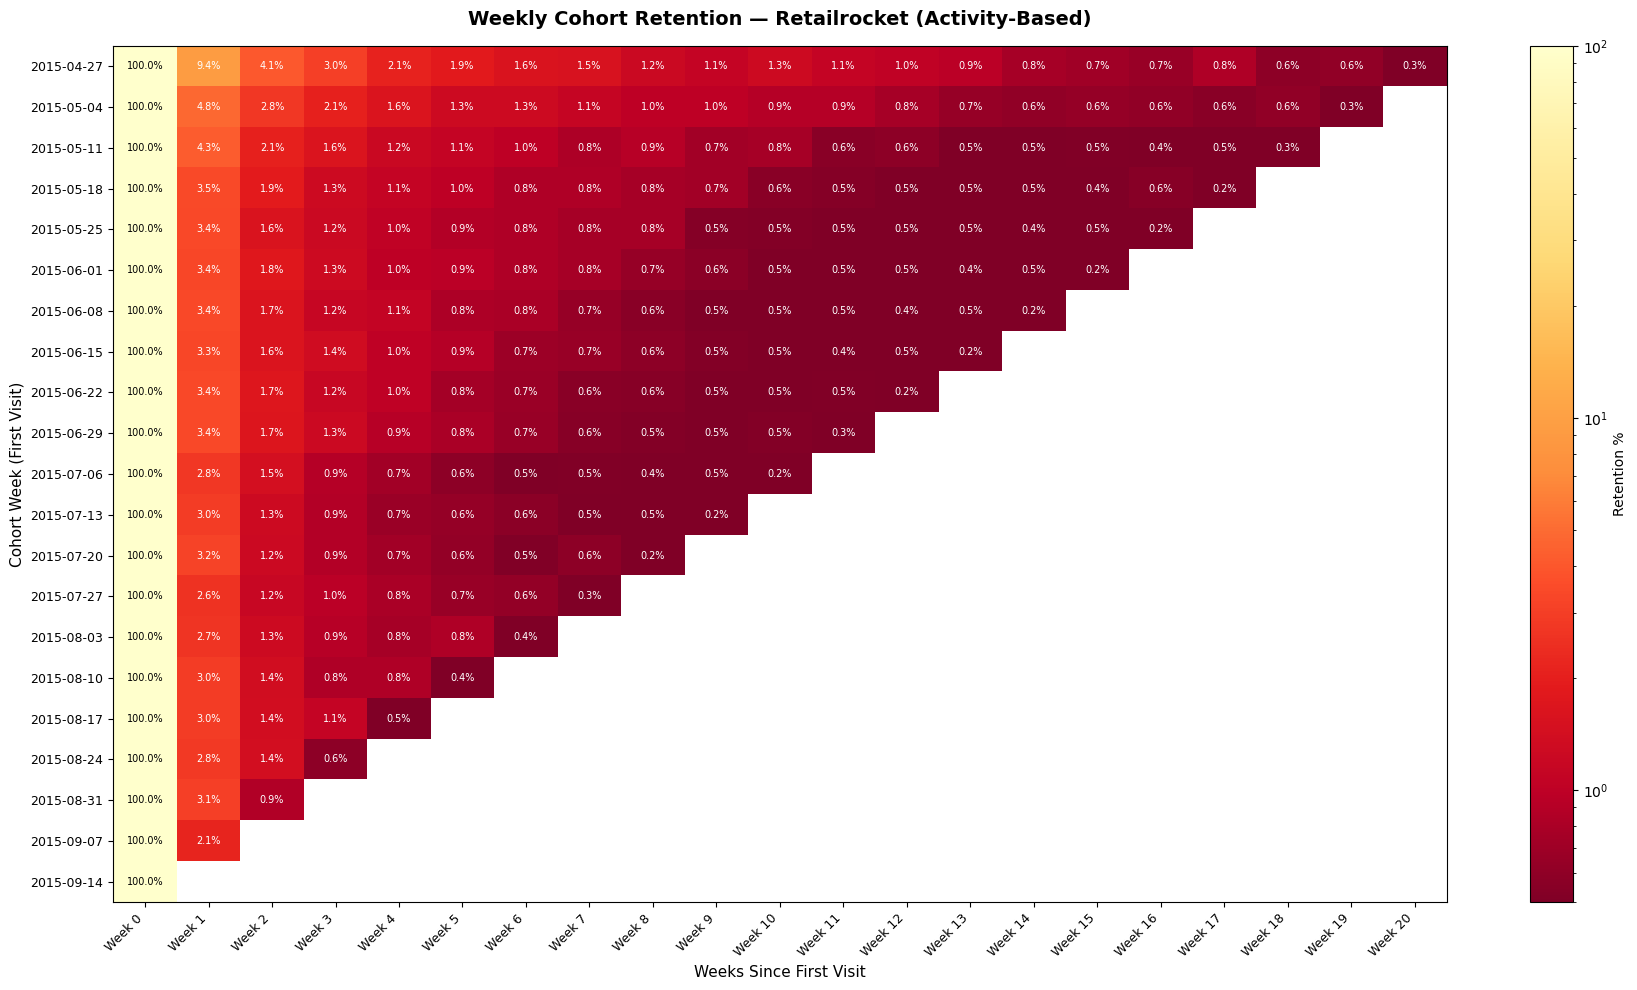

In [22]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# Pivot to heatmap format
cohort_pivot = cohort_retention.pivot_table(
    index='cohort_week', columns='weeks_since_cohort', values='retention_pct'
)
cohort_pivot.index = cohort_pivot.index.astype(str).str[:10]

fig, ax = plt.subplots(figsize=(18, 10))

# Log scale: retention drops from 100% to <1% — log scale spreads the colour range
im = ax.imshow(
    cohort_pivot.values, cmap='YlOrRd_r', aspect='auto',
    norm=mcolors.LogNorm(vmin=0.5, vmax=100)
)

for i in range(len(cohort_pivot.index)):
    for j in range(len(cohort_pivot.columns)):
        val = cohort_pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                   fontsize=7, color='black' if val > 10 else 'white')

ax.set_xticks(range(len(cohort_pivot.columns)))
ax.set_xticklabels([f'Week {c}' for c in cohort_pivot.columns], rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(cohort_pivot.index)))
ax.set_yticklabels(cohort_pivot.index, fontsize=9)
ax.set_title('Weekly Cohort Retention — Retailrocket (Activity-Based)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Weeks Since First Visit', fontsize=11)
ax.set_ylabel('Cohort Week (First Visit)', fontsize=11)
plt.colorbar(im, ax=ax, label='Retention %')
plt.tight_layout()
plt.show()

In [23]:
# Save cohort data
cohort_retention.to_parquet(f"{SILVER}/cohort_retention.parquet", index=False)

### Interpretation — Cohort Retention

- Every cohort begins with **100% activity in Week 0**, representing users during their first week of engagement.
- User retention drops sharply after the initial visit, with **Week 1 retention ranging between approximately 3–9%** across most cohorts — meaning 91–97% of users do not return the following week.
- After the first few weeks, retention continues to decline gradually, stabilising below **1%** for older cohorts by Weeks 15–20.
- The retention pattern is consistent across all 21 acquisition cohorts, indicating no significant improvement or deterioration in user engagement over the observed period.
- Overall, the analysis indicates that while the platform consistently attracts new users, **retaining users beyond their initial visit remains the primary engagement challenge**.


### 4b — Repeat Purchase Analysis

Among buyers, how many return to purchase more than once? We count purchasing sessions rather than individual transaction events — each session represents a deliberate decision to return and buy.

In [24]:
repeat_purchase = con.execute(f"""
    WITH purchasing_sessions AS (
        SELECT DISTINCT visitorid, session_id
        FROM read_parquet('{SILVER}/session_summary.parquet')
        WHERE outcome = 'transaction'
    ),
    user_purchase_counts AS (
        SELECT visitorid, COUNT(session_id) AS purchase_sessions
        FROM purchasing_sessions
        GROUP BY visitorid
    ),
    bucketed AS (
        SELECT visitorid, purchase_sessions,
            CASE
                WHEN purchase_sessions = 1  THEN '1 purchase'
                WHEN purchase_sessions = 2  THEN '2 purchases'
                WHEN purchase_sessions = 3  THEN '3 purchases'
                WHEN purchase_sessions >= 4 THEN '4+ purchases'
            END AS purchase_bucket
        FROM user_purchase_counts
    )
    SELECT
        purchase_bucket,
        COUNT(visitorid) AS user_count,
        SUM(purchase_sessions) AS total_purchase_sessions,
        ROUND(100.0 * COUNT(visitorid)
              / SUM(COUNT(visitorid)) OVER (), 2)  AS pct_of_buyers,
        ROUND(100.0 * SUM(purchase_sessions)
              / SUM(SUM(purchase_sessions)) OVER (), 2) AS pct_of_purchase_sessions
    FROM bucketed
    GROUP BY purchase_bucket
    ORDER BY
        CASE purchase_bucket
            WHEN '1 purchase'   THEN 1
            WHEN '2 purchases'  THEN 2
            WHEN '3 purchases'  THEN 3
            WHEN '4+ purchases' THEN 4
        END
""").df()

print(repeat_purchase.to_string())

total_buyers   = repeat_purchase['user_count'].sum()
repeat_buyers  = repeat_purchase[repeat_purchase['purchase_bucket'] != '1 purchase']['user_count'].sum()
repeat_rate    = round(100 * repeat_buyers / total_buyers, 2)
print(f"\nTotal unique buyers:  {total_buyers:,}")
print(f"Repeat buyers (2+):   {repeat_buyers:,}")
print(f"Repeat purchase rate: {repeat_rate}%")

  purchase_bucket  user_count  total_purchase_sessions  pct_of_buyers  pct_of_purchase_sessions
0      1 purchase       11033                  11033.0          94.15                     77.17
1     2 purchases         476                    952.0           4.06                      6.66
2     3 purchases          80                    240.0           0.68                      1.68
3    4+ purchases         130                   2072.0           1.11                     14.49

Total unique buyers:  11,719
Repeat buyers (2+):   686
Repeat purchase rate: 5.85%


In [25]:
repeat_purchase.to_parquet(f"{SILVER}/repeat_purchase.parquet", index=False)
print("Repeat purchase data saved.")

Repeat purchase data saved.


### Interpretation — Repeat Purchase

- A total of **11,719 unique users** completed at least one purchase during the observation period.
- **94.15% of buyers made only one purchase session**, while only **5.85% returned to make a second or subsequent purchase**, indicating low observed repeat purchasing.
- The **4+ purchase segment represented just 1.11% of buyers but generated 14.49% of all purchase occasions**, highlighting a small but disproportionately active group of customers.
- Customers with **exactly two purchase sessions (4.06% of buyers)** represent a promising retention opportunity — they have already demonstrated willingness to return and are one step from becoming frequent buyers.

> **Note:** This analysis uses cookie-based visitor identifiers. Users returning on different devices or after clearing browser cookies may be recorded as new visitors, which can underestimate repeat purchasing and overestimate the proportion of one-time buyers.


### 4c — Lifetime Purchase Activity

Extending the repeat purchase analysis to the full user base (including the 99%+ who never purchased) reveals the full concentration of purchasing activity.

In [26]:
lifetime_activity = con.execute(f"""
    WITH all_users AS (
        SELECT DISTINCT visitorid
        FROM read_parquet('{SILVER}/session_summary.parquet')
    ),
    purchasing_sessions AS (
        SELECT visitorid, COUNT(session_id) AS purchase_sessions
        FROM read_parquet('{SILVER}/session_summary.parquet')
        WHERE outcome = 'transaction'
        GROUP BY visitorid
    ),
    user_activity AS (
        SELECT u.visitorid, COALESCE(p.purchase_sessions, 0) AS purchase_sessions
        FROM all_users u
        LEFT JOIN purchasing_sessions p ON u.visitorid = p.visitorid
    ),
    bucketed AS (
        SELECT visitorid, purchase_sessions,
            CASE
                WHEN purchase_sessions = 0  THEN '0 purchases - Never Converted'
                WHEN purchase_sessions = 1  THEN '1 purchase - One-time Buyers'
                WHEN purchase_sessions = 2  THEN '2 purchases - Early Repeat Buyers'
                WHEN purchase_sessions >= 3 THEN '3+ purchases - Frequent Buyers'
            END AS purchase_bucket
        FROM user_activity
    )
    SELECT
        purchase_bucket,
        COUNT(visitorid) AS user_count,
        SUM(purchase_sessions) AS total_purchase_sessions,
        ROUND(100.0 * COUNT(visitorid)
              / SUM(COUNT(visitorid)) OVER (), 2) AS pct_of_users,
        ROUND(100.0 * SUM(purchase_sessions)
              / NULLIF(SUM(SUM(purchase_sessions)) OVER (), 0), 2) AS pct_of_purchase_sessions
    FROM bucketed
    GROUP BY purchase_bucket
    ORDER BY
        CASE purchase_bucket
            WHEN '0 purchases - Never Converted' THEN 1
            WHEN '1 purchase - One-time Buyers' THEN 2
            WHEN '2 purchases - Early Repeat Buyers'  THEN 3
            WHEN '3+ purchases - Frequent Buyers' THEN 4
        END
""").df()

print(lifetime_activity.to_string())

lifetime_activity.to_parquet(f"{SILVER}/lifetime_activity.parquet", index=False)

                     purchase_bucket  user_count  total_purchase_sessions  pct_of_users  pct_of_purchase_sessions
0      0 purchases - Never Converted     1395861                      0.0         99.17                      0.00
1       1 purchase - One-time Buyers       11033                  11033.0          0.78                     77.17
2  2 purchases - Early Repeat Buyers         476                    952.0          0.03                      6.66
3     3+ purchases - Frequent Buyers         210                   2312.0          0.01                     16.17


In [27]:
# Supplementary concentration metrics
lifetime_activity['avg_purchases_per_user'] = (
    lifetime_activity['total_purchase_sessions'] / lifetime_activity['user_count']
).round(2)
print("Average purchase sessions per user by segment:")
print(lifetime_activity[['purchase_bucket', 'avg_purchases_per_user']].to_string())

repeat_txns  = lifetime_activity[~lifetime_activity['purchase_bucket'].str.contains('Never|One-time')]['total_purchase_sessions'].sum()
total_txns   = lifetime_activity['total_purchase_sessions'].sum()
repeat_share = round(100 * repeat_txns / total_txns, 2)
print(f"\nShare of purchase sessions from repeat buyers (2+): {repeat_share}%")

buyer_txns   = lifetime_activity[~lifetime_activity['purchase_bucket'].str.contains('Never')]['total_purchase_sessions'].sum()
buyer_users  = lifetime_activity[~lifetime_activity['purchase_bucket'].str.contains('Never')]['user_count'].sum()
avg_freq     = round(buyer_txns / buyer_users, 2)
print(f"Average purchase sessions per buyer: {avg_freq}")

Average purchase sessions per user by segment:
                     purchase_bucket  avg_purchases_per_user
0      0 purchases - Never Converted                    0.00
1       1 purchase - One-time Buyers                    1.00
2  2 purchases - Early Repeat Buyers                    2.00
3     3+ purchases - Frequent Buyers                   11.01

Share of purchase sessions from repeat buyers (2+): 22.83%
Average purchase sessions per buyer: 1.22


### Interpretation — Lifetime Purchase Activity

- Of the **1.41 million users** in the dataset, **99.17% did not complete a purchase** during the observation period. Initial conversion represents the largest opportunity within the customer journey.
- Among the **11,719 buyers**, only **5.85% returned to make a second or subsequent purchase**, suggesting that repeat purchasing is limited within this dataset.
- Purchasing activity is highly concentrated: **Frequent Buyers (3+ purchase sessions)** represent only **0.01% of the total user base**, yet account for **16.17% of all purchase sessions**.
- Repeat buyers (2 or more purchase sessions) contribute **22.83% of all purchase sessions** despite representing only 686 users, demonstrating the importance of customer retention in driving overall purchase activity.
- On average, **Frequent Buyers completed approximately 11 purchase sessions each**, indicating a small cohort of highly engaged customers who repeatedly return to purchase.
- **Early Repeat Buyers (476 users)** have already demonstrated willingness to return for a second purchase, making them a natural target for retention initiatives.

> **Note:** Cookie-based identifiers may underestimate repeat purchasing if users return on different devices or after clearing cookies.


### 4d — Retention Opportunity Scenario Model

If a percentage of one-time buyers made exactly one additional purchase session, how much would total purchase volume increase? This is a scenario analysis — not a forecast or revenue projection.

In [28]:
# Base numbers derived from data — not hardcoded
one_time_buyers = lifetime_activity.loc[
    lifetime_activity['purchase_bucket'].str.contains('One-time'), 'user_count'
].iloc[0]

current_total = int(lifetime_activity['total_purchase_sessions'].sum())
additional_per_convert = 1  # one-time → early repeat: exactly +1 session

print(f"Base: one-time buyers = {one_time_buyers:,}")
print(f"Base: total purchase sessions = {current_total:,}")

scenarios = [0.05, 0.10, 0.20]
scenario_results = []

for pct in scenarios:
    converted = round(one_time_buyers * pct)
    additional = converted * additional_per_convert
    new_total = current_total + additional
    pct_increase = round(100 * additional / current_total, 2)
    scenario_results.append({
        'scenario' : f'{int(pct*100)}% of one-time buyers return once',
        'users_converted' : converted,
        'additional_purchase_sessions': additional,
        'new_total_purchase_sessions' : new_total,
        'pct_increase' : pct_increase
    })

scenario_df = pd.DataFrame(scenario_results)
print("\nRetention Opportunity Scenarios:")
print(scenario_df.to_string())

scenario_df.to_parquet(f"{SILVER}/retention_scenario.parquet", index=False)
print("\nScenario model saved.")

Base: one-time buyers = 11,033
Base: total purchase sessions = 14,297

Retention Opportunity Scenarios:
                             scenario  users_converted  additional_purchase_sessions  new_total_purchase_sessions  pct_increase
0   5% of one-time buyers return once              552                           552                        14849          3.86
1  10% of one-time buyers return once             1103                          1103                        15400          7.71
2  20% of one-time buyers return once             2207                          2207                        16504         15.44

Scenario model saved.


### Interpretation — Retention Scenario

- This scenario analysis illustrates the potential impact of improving customer retention under a simple, transparent assumption: a subset of **one-time buyers returns for exactly one additional purchase session**. It quantifies potential changes in purchase activity rather than predicting future outcomes. No revenue assumptions are made — scenarios quantify changes in purchase session volume.
- Even under the **5% scenario**, converting **552 one-time buyers** into early repeat buyers would generate **552 additional purchase sessions**, increasing total purchase activity by **3.86%**.
- Under the **10% and 20% scenarios**, total purchase sessions increase by **7.71%** and **15.44%** respectively, demonstrating that relatively small improvements in repeat purchasing could have a meaningful impact on overall purchasing activity.
- These findings motivate a scenario analysis: even a modest improvement in the proportion of one-time buyers who return for a second purchase could meaningfully increase total transaction volume, given the disproportionate activity of frequent buyers.


---
## Section 5 — Recommendations and Validation

### 5a. Prioritised Recommendations

#### 1. Nudge Deliberate Considerers at the Second Repeat View (Highest Priority)

Repeated product views were associated with a substantial increase in observed conversion rates, with the largest improvement occurring between the first and second repeat view. Additionally, **177,105 sessions** repeatedly viewed the same product without completing a purchase, representing the largest high-intent segment identified in the analysis. A personalised **"Still interested?"** reminder triggered when a user reaches their second repeated product view may encourage purchase completion while requiring only a lightweight product intervention. The scenario analysis in Section 4 further suggests that even modest improvements in repeat purchasing among this segment could meaningfully increase overall purchase session volume.

#### 2. Recover Cart Abandoners (High Priority)

The analysis identified **31,992 cart abandonment sessions**, indicating that many users progressed to the highest stage of purchase intent without completing a transaction. A session-end cart reminder or follow-up notification could encourage these users to complete their purchase. However, this recommendation should be interpreted cautiously, as factors such as pricing, shipping costs, payment issues, or stock availability are not observable within the dataset.

#### 3. Improve First-Impression Relevance (Medium Priority)

Approximately **78% of sessions** consisted of a single product view with almost no measurable engagement, suggesting that many visitors leave before meaningfully exploring the catalogue. This pattern is more consistent with a relevance or targeting problem at acquisition than a product friction problem. Improving landing page relevance, recommendation quality, or product discovery may encourage deeper browsing and increase opportunities for future conversion.

#### 4. Encourage Third Purchase Among Early Repeat Buyers (Medium Priority)

Although **Early Repeat Buyers** represent a relatively small customer segment, they have already demonstrated a willingness to return for a second purchase. The analysis also showed that **Frequent Buyers average approximately 11 purchase sessions each**, highlighting the long-term value of customers who develop repeat purchasing habits. Loyalty incentives or personalised offers encouraging a third purchase may help more customers transition into this high-value segment.

---

### 5b. Experiment Design

To evaluate the highest-priority recommendation, an A/B experiment is proposed targeting users who **reach their second repeated view of the same product and have not yet completed a purchase**. At this decision point, eligible sessions would be randomly assigned to either a **Control** group (normal browsing experience) or a **Treatment** group (personalised "Still interested?" reminder). The primary evaluation metric is **session conversion rate**, defined as the proportion of eligible sessions resulting in a completed purchase.

The historical behavioural segmentation identified **Deliberate Considerers** based on the final session outcome (no purchase), whereas the experiment randomises users before that outcome is known. Consequently, an exact historical baseline conversion rate for the intervention population is unavailable. Instead, the observed **2.50% conversion rate among sessions with two repeated product views** is used as an approximate benchmark for experiment planning rather than the true baseline conversion rate of the intervention group.

For sample size planning, the experiment targets a **20% relative improvement** in conversion rate (from **2.50% to 3.00%**). This Minimum Detectable Effect (MDE) represents a practically meaningful improvement for a lightweight behavioural intervention while remaining realistic for an e-commerce personalisation experiment. The MDE is used solely as a planning parameter and should not be interpreted as a predicted outcome.

---

### 5c. Statistical Power and Feasibility


In [29]:
import numpy as np
from scipy import stats

#  Experiment parameters 
baseline_rate  = 0.025   # 2.5% — approximate benchmark from Q3 two-view sessions
relative_lift  = 0.20    # 20% relative MDE
treatment_rate = baseline_rate * (1 + relative_lift)   # planned detectable rate: 3.0%
alpha = 0.05    # significance level (two-tailed)
power = 0.80    # statistical power

print("Experiment Parameters ")
print(f"Baseline conversion rate:              {baseline_rate*100:.2f}%")
print(f"Planned detectable conversion rate:    {treatment_rate*100:.2f}%")
print(f"Minimum Detectable Effect:             {relative_lift*100:.0f}% relative lift")
print(f"Absolute difference:                   {(treatment_rate-baseline_rate)*100:.2f} pp")
print(f"Significance level (α):                {alpha}")
print(f"Statistical power (1-β):               {power}")

#  Sample size (standard two-proportion z-test) 
z_alpha  = stats.norm.ppf(1 - alpha/2)
z_beta   = stats.norm.ppf(power)
p1, p2   = baseline_rate, treatment_rate
p_pooled = (p1 + p2) / 2

numerator   = (z_alpha * np.sqrt(2 * p_pooled * (1 - p_pooled)) +
               z_beta  * np.sqrt(p1 * (1 - p1) + p2 * (1 - p2))) ** 2
denominator = (p2 - p1) ** 2

n_per_group = int(np.ceil(numerator / denominator))
n_total     = n_per_group * 2

print(f"\n Sample Size Required")
print(f"Per group:                             {n_per_group:,}")
print(f"Total (both groups):                   {n_total:,}")

#  Duration estimate 
# Eligible sessions from Q3 (mutually exclusive buckets, no double counting):
#   2 views: 150,099 | 3 views: 30,938 | 4+ views: 16,417 = 197,454 total
eligible_total  = 197454
dataset_weeks   = 19.5
weekly_eligible = eligible_total / dataset_weeks
weeks_needed    = np.ceil(n_total / weekly_eligible)
months_needed   = round(weeks_needed / 4.33, 1)

print(f"\n Experiment Duration Estimate")
print(f"Weekly eligible sessions: {weekly_eligible:,.0f}")
print(f"Weeks needed: {int(weeks_needed)}")
print(f"Estimated duration: ~{months_needed} months")
print(f"\nNote: Assumes 100% traffic allocation with no ramp-up,")
print(f"QA periods, or holdouts. Real experiments would run longer.")

# Save
power_calc = pd.DataFrame([{
    'baseline_rate': baseline_rate, 'planned_detectable_rate': treatment_rate,
    'relative_lift_pct': relative_lift * 100, 'alpha': alpha, 'power': power,
    'n_per_group': n_per_group, 'n_total': n_total,
    'weekly_eligible': round(weekly_eligible), 'weeks_needed': int(weeks_needed),
    'months_needed': months_needed
}])
power_calc.to_parquet(f"{SILVER}/power_calculation.parquet", index=False)
print("\nPower calculation saved.")

Experiment Parameters 
Baseline conversion rate:              2.50%
Planned detectable conversion rate:    3.00%
Minimum Detectable Effect:             20% relative lift
Absolute difference:                   0.50 pp
Significance level (α):                0.05
Statistical power (1-β):               0.8

 Sample Size Required
Per group:                             16,792
Total (both groups):                   33,584

 Experiment Duration Estimate
Weekly eligible sessions: 10,126
Weeks needed: 4
Estimated duration: ~0.9 months

Note: Assumes 100% traffic allocation with no ramp-up,
QA periods, or holdouts. Real experiments would run longer.

Power calculation saved.


### Interpretation — Statistical Power

Using a two-sample proportion test with a **5% significance level (α = 0.05)** and **80% statistical power**, the experiment requires approximately **16,792 eligible sessions per group**, or **33,584 sessions in total**, to reliably detect the planned effect size.

Based on the observed volume of eligible sessions within the dataset, approximately **10,126 qualifying sessions** would be available each week, resulting in an estimated experiment duration of **approximately four weeks** under full traffic allocation. This estimate assumes that all eligible sessions are available for randomisation, traffic remains relatively stable throughout the experiment, and no operational constraints (such as staged rollouts, traffic throttling, or quality assurance periods) reduce experiment exposure. Under these assumptions, the proposed experiment appears operationally feasible while providing sufficient statistical power to evaluate the intervention.

---

## Project Limitations

| Limitation | Implication |
|---|---|
| Cookie-based visitor IDs | Repeat behaviour may be undercounted; users on multiple devices appear as new visitors |
| No revenue or pricing data | All value metrics in purchase session counts, not monetary terms |
| 4.5-month observation window | Later cohorts have limited follow-up data (right censoring in cohort analysis) |
| Observational data only | All associations are correlational — causation requires the experiment in Section 5 |
| Single platform snapshot | Findings reflect this platform and time period; generalisability is limited |
